In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error

In [8]:
train = pd.read_csv("../data/stock_3_train.csv")
test = pd.read_csv("../data/stock_3_test.csv")

print(f"Train: {train.shape[0]} rows, {train.shape[1]-1} features")
print(f"Test: {test.shape[0]} row")
train.head()

Train: 29 rows, 4 features
Test: 1 row


,col_0,col_1,col_2,col_3,target
0,0.840308,-1.727320,0.434424,0.237736,235.557618
1,-1.682870,-0.334885,0.162753,0.586222,293.389951
2,0.857976,-0.191304,-1.275686,-1.133287,174.757576
3,-0.512243,-0.813773,0.615979,1.128972,249.763034
4,-0.113947,-0.840156,-0.824481,0.650593,260.280987


In [9]:
train.describe()

,col_0,col_1,col_2,col_3,target
count,29.000000,29.000000,29.000000,29.000000,29.000000
mean,-0.211130,-0.177203,0.216951,0.046872,205.494215
std,0.790250,0.830990,0.792592,0.614647,78.761369
min,-1.951035,-1.727320,-1.275686,-1.133287,80.000000
25%,-0.594150,-0.840156,-0.363054,-0.381738,151.042167
50%,-0.113947,-0.205438,0.289119,-0.049926,198.993083
75%,0.412733,0.446531,0.665385,0.631288,249.763034
max,0.857976,1.494941,2.141648,1.128972,399.999999


In [10]:
print(train.isnull().any())
print()
print(train.dtypes)

col_0     False
col_1     False
col_2     False
col_3     False
target    False
dtype: bool

col_0     float64
col_1     float64
col_2     float64
col_3     float64
target    float64
dtype: object


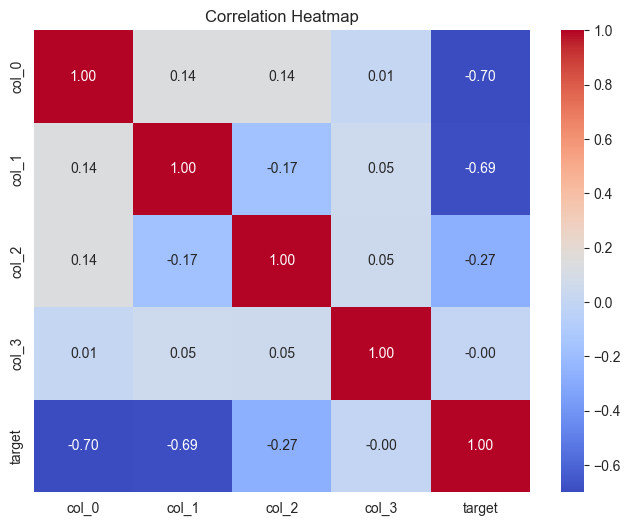


Correlation with target:
col_0   -0.699687
col_1   -0.688900
col_2   -0.268650
col_3   -0.002453
Name: target, dtype: float64


In [11]:
corr = train.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with target:")
print(corr['target'].drop('target').sort_values(key=abs, ascending=False))

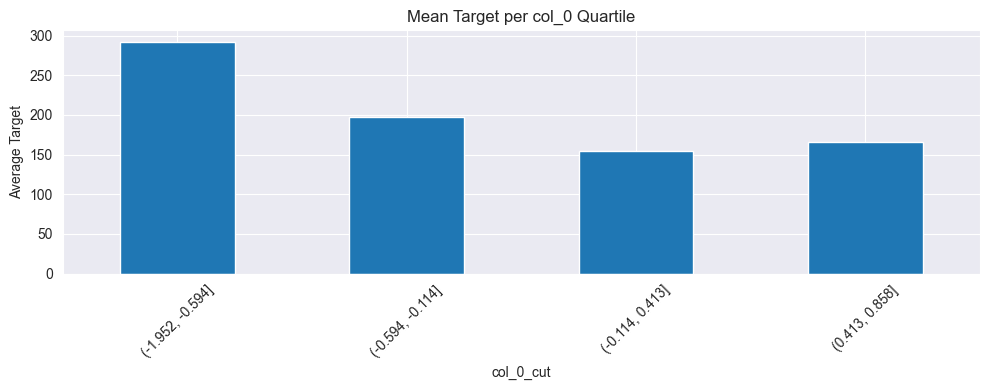

col_0_cut
(-1.952, -0.594]    291.885668
(-0.594, -0.114]    197.700871
(-0.114, 0.413]     154.550003
(0.413, 0.858]      165.498682
Name: target, dtype: float64



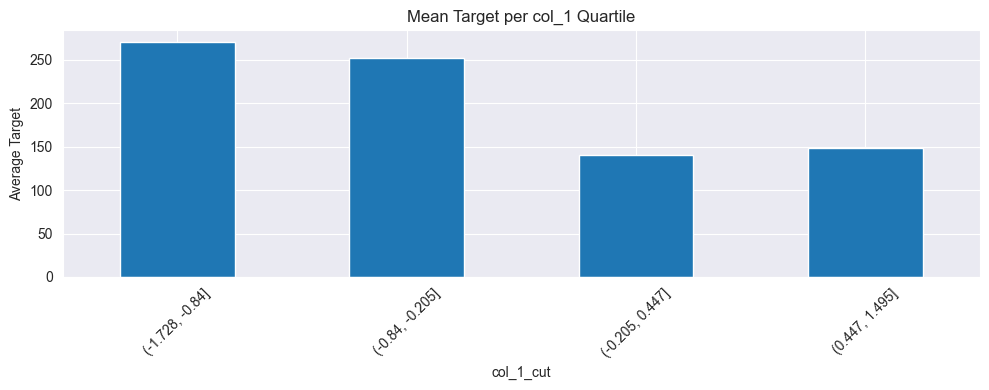

col_1_cut
(-1.728, -0.84]    270.391285
(-0.84, -0.205]    252.496124
(-0.205, 0.447]    140.870481
(0.447, 1.495]     148.947960
Name: target, dtype: float64



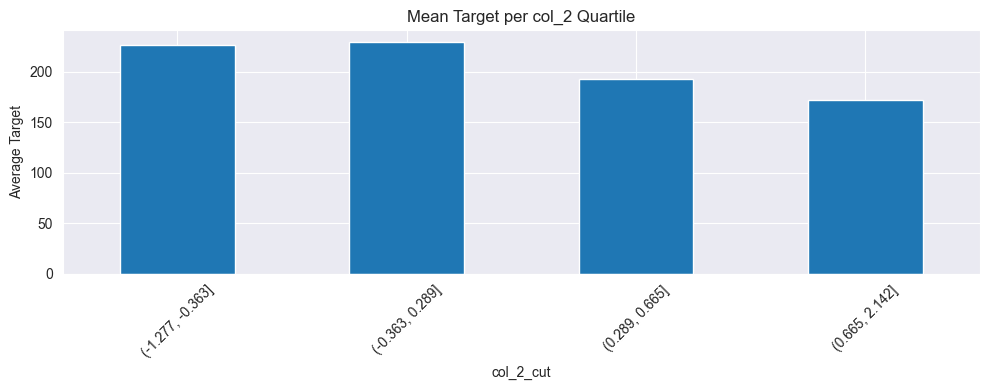

col_2_cut
(-1.277, -0.363]    225.775033
(-0.363, 0.289]     229.218576
(0.289, 0.665]      192.299907
(0.665, 2.142]      171.786084
Name: target, dtype: float64



In [12]:
for col in ['col_0', 'col_1', 'col_2']:
    train[f'{col}_cut'] = pd.qcut(train[col], 4, duplicates='drop')

    fig, ax = plt.subplots(figsize=(10, 4))
    group = train.groupby(f'{col}_cut', observed=True)['target'].mean()
    group.plot(kind='bar', ax=ax)
    ax.set_title(f'Mean Target per {col} Quartile')
    ax.set_ylabel('Average Target')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(train.groupby(f'{col}_cut', observed=True)['target'].mean())
    print()

In [13]:
X = train[['col_0', 'col_1', 'col_2', 'col_3']]
y = train['target']

lr_all = LinearRegression().fit(X, y)

print(f"R²: {lr_all.score(X, y):.6f}")
print(f"Intercept: {lr_all.intercept_:.4f}")
for col, coef in zip(X.columns, lr_all.coef_):
    print(f"  {col}: {coef:.4f}")

R²: 0.935451
Intercept: 188.7585
  col_0: -56.1857
  col_1: -63.1074
  col_2: -30.4966
  col_3: 6.5446


In [14]:
X_clean = train[['col_0', 'col_1', 'col_2']]
y = train['target']

lr_clean = LinearRegression().fit(X_clean, y)

print(f"R² (3 features): {lr_clean.score(X_clean, y):.6f}")
print(f"Intercept: {lr_clean.intercept_:.4f}")
for col, coef in zip(X_clean.columns, lr_clean.coef_):
    print(f"  {col}: {coef:.4f}")

R² (3 features): 0.932859
Intercept: 189.0447
  col_0: -56.2309
  col_1: -62.8016
  col_2: -30.1960


In [15]:
loo = LeaveOneOut()

models = {
    'Linear (all 4)': ('linear', ['col_0', 'col_1', 'col_2', 'col_3']),
    'Linear (3 feat)': ('linear', ['col_0', 'col_1', 'col_2']),
    'Linear (2 feat)': ('linear', ['col_0', 'col_1']),
    'Ridge a=1': ('ridge1', ['col_0', 'col_1', 'col_2']),
    'Ridge a=10': ('ridge10', ['col_0', 'col_1', 'col_2']),
    'Ridge a=100': ('ridge100', ['col_0', 'col_1', 'col_2']),
}

print(f"{'Model':<20} {'LOO RMSE':>10} {'LOO MAE':>10}")
print("-" * 42)

for name, (mtype, cols) in models.items():
    X_m = train[cols]

    if mtype == 'linear':
        model = LinearRegression()
    elif mtype == 'ridge1':
        model = Ridge(alpha=1)
    elif mtype == 'ridge10':
        model = Ridge(alpha=10)
    elif mtype == 'ridge100':
        model = Ridge(alpha=100)

    scores_mse = cross_val_score(model, X_m, y, cv=loo, scoring='neg_mean_squared_error')
    scores_mae = cross_val_score(model, X_m, y, cv=loo, scoring='neg_mean_absolute_error')

    rmse = np.sqrt(-scores_mse.mean())
    mae = -scores_mae.mean()

    print(f"{name:<20} {rmse:>10.2f} {mae:>10.2f}")

Model                  LOO RMSE    LOO MAE
------------------------------------------
Linear (all 4)            24.65      19.08
Linear (3 feat)           23.83      17.61
Linear (2 feat)           34.31      27.89
Ridge a=1                 24.03      17.86
Ridge a=10                36.33      29.73
Ridge a=100               69.18      54.40


In [16]:
X_clean = train[['col_0', 'col_1', 'col_2']]
y = train['target']
lr = LinearRegression().fit(X_clean, y)
residuals = y - lr.predict(X_clean)

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std: {residuals.std():.4f}")
print(f"Residual skew: {residuals.skew():.4f}")
print(f"Residual kurtosis: {residuals.kurtosis():.4f}")

print("\nCorrelation of residuals with squared features:")
for col in ['col_0', 'col_1', 'col_2']:
    corr_sq = np.corrcoef(residuals, train[col]**2)[0, 1]
    print(f"  resid vs {col}²: {corr_sq:.4f}")

print("\nCorrelation of residuals with interactions:")
pairs = [('col_0','col_1'), ('col_0','col_2'), ('col_1','col_2')]
for c1, c2 in pairs:
    interaction = train[c1] * train[c2]
    corr = np.corrcoef(residuals, interaction)[0, 1]
    print(f"  resid vs {c1}*{c2}: {corr:.4f}")

Residual mean: -0.0000
Residual std: 20.4084
Residual skew: 1.0769
Residual kurtosis: 1.2414

Correlation of residuals with squared features:
  resid vs col_0²: 0.1515
  resid vs col_1²: 0.2599
  resid vs col_2²: 0.0258

Correlation of residuals with interactions:
  resid vs col_0*col_1: 0.1345
  resid vs col_0*col_2: 0.2240
  resid vs col_1*col_2: -0.2348


In [17]:
train['col_0_col_1_diff'] = train['col_0'] - train['col_1']
train['col_1_col_2_diff'] = train['col_1'] - train['col_2']
train['col_0_col_2_diff'] = train['col_0'] - train['col_2']

print("Correlation of engineered features with target:")
for feat in ['col_0_col_1_diff', 'col_1_col_2_diff', 'col_0_col_2_diff']:
    corr = train[feat].corr(train['target'])
    print(f"  {feat}: {corr:.4f}")

Correlation of engineered features with target:
  col_0_col_1_diff: 0.0184
  col_1_col_2_diff: -0.2891
  col_0_col_2_diff: -0.3277


In [18]:
best_diff = train[['col_0_col_1_diff']]
lr_diff = LinearRegression().fit(best_diff, y)
leftover = y - lr_diff.predict(best_diff)

print("Correlation of leftover with remaining features:")
for col in ['col_0', 'col_1', 'col_2', 'col_3']:
    corr = np.corrcoef(leftover, train[col])[0, 1]
    print(f"  leftover vs {col}: {corr:.4f}")

Correlation of leftover with remaining features:
  leftover vs col_0: -0.7114
  leftover vs col_1: -0.6766
  leftover vs col_2: -0.2731
  leftover vs col_3: -0.0018


In [19]:
X_3 = train[['col_0', 'col_1', 'col_2']]

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_3)

print(f"Polynomial features: {poly.get_feature_names_out()}")
print(f"Number of features: {X_poly.shape[1]} (from {X_3.shape[1]} original)")
print(f"Number of rows: {X_poly.shape[0]}")
print(f"Features/rows ratio: {X_poly.shape[1]/X_poly.shape[0]:.2f} (>0.3 is dangerous)")

loo = LeaveOneOut()

scores_lin = cross_val_score(LinearRegression(), X_3, y, cv=loo, scoring='neg_mean_squared_error')
rmse_lin = np.sqrt(-scores_lin.mean())

scores_poly = cross_val_score(LinearRegression(), X_poly, y, cv=loo, scoring='neg_mean_squared_error')
rmse_poly = np.sqrt(-scores_poly.mean())

scores_rpoly = cross_val_score(Ridge(alpha=10), X_poly, y, cv=loo, scoring='neg_mean_squared_error')
rmse_rpoly = np.sqrt(-scores_rpoly.mean())

print(f"\nLOO RMSE — Linear (raw):        {rmse_lin:.2f}")
print(f"LOO RMSE — Linear (poly deg 2): {rmse_poly:.2f}")
print(f"LOO RMSE — Ridge (poly deg 2):  {rmse_rpoly:.2f}")

Polynomial features: ['col_0' 'col_1' 'col_2' 'col_0^2' 'col_0 col_1' 'col_0 col_2' 'col_1^2'
 'col_1 col_2' 'col_2^2']
Number of features: 9 (from 3 original)
Number of rows: 29
Features/rows ratio: 0.31 (>0.3 is dangerous)

LOO RMSE — Linear (raw):        23.83
LOO RMSE — Linear (poly deg 2): 30.69
LOO RMSE — Ridge (poly deg 2):  34.80


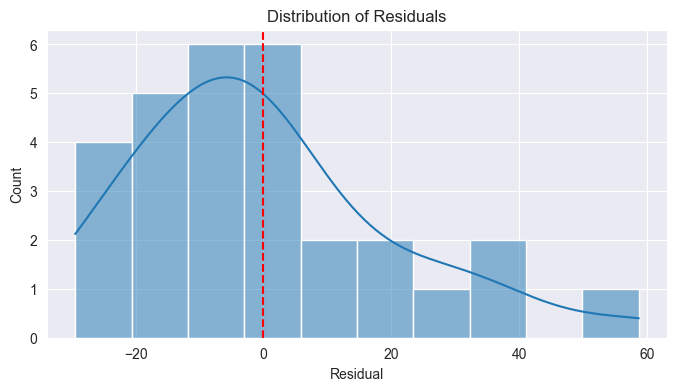

Noise std: 20.41


In [20]:
X_clean = train[['col_0', 'col_1', 'col_2']]
y = train['target']
lr = LinearRegression().fit(X_clean, y)
residuals = y - lr.predict(X_clean)

plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, bins=10)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.show()

print(f"Noise std: {residuals.std():.2f}")

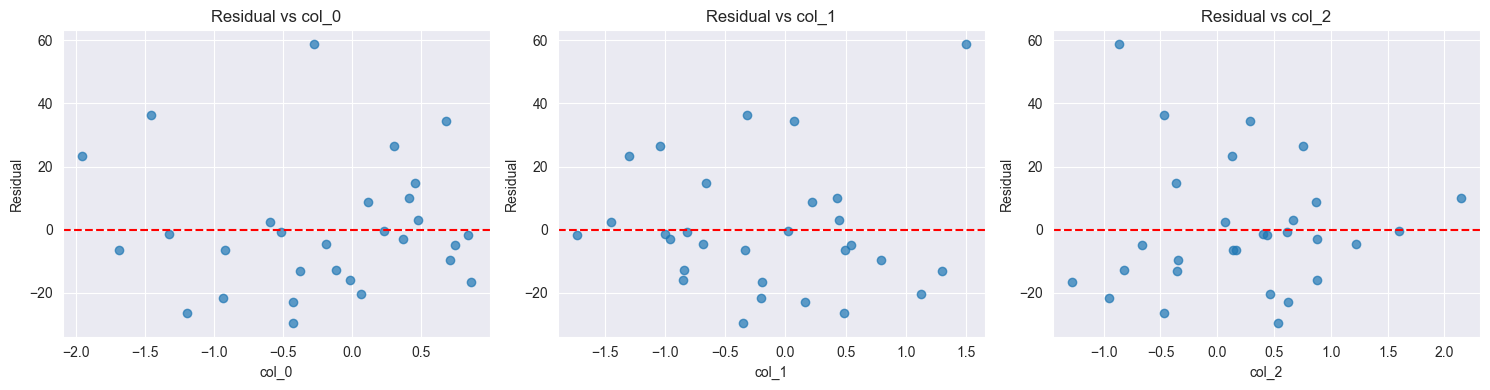

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['col_0', 'col_1', 'col_2']):
    ax.scatter(train[col], residuals, alpha=0.7)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel(col)
    ax.set_ylabel('Residual')
    ax.set_title(f'Residual vs {col}')

plt.tight_layout()
plt.show()

In [23]:
library = {
    'log_col0': np.log(np.abs(train['col_0']) + 1),
    'log_col1': np.log(np.abs(train['col_1']) + 1),
    'sq_col0': train['col_0']**2,
    'sq_col1': train['col_1']**2,
    'interaction_01': train['col_0'] * train['col_1'],
    'interaction_02': train['col_0'] * train['col_2'],
    'interaction_12': train['col_1'] * train['col_2'],
    'sign_col0': np.sign(train['col_0']),
    'sign_col1': np.sign(train['col_1']),
    'sin_col0': np.sin(train['col_0']),
    'sin_col1': np.sin(train['col_1']),
    'abs_col0': np.abs(train['col_0']),
    'abs_col1': np.abs(train['col_1']),
    'col0_cube': train['col_0']**3,
    'col1_cube': train['col_1']**3,
}

print("Correlation of engineered features with residuals:")
print(f"{'Feature':<20} {'Corr with residual':>20}")
print("-" * 42)

for name, feature in sorted(library.items(), key=lambda x: abs(np.corrcoef(x[1], residuals)[0,1]), reverse=True):
    corr = np.corrcoef(feature, residuals)[0, 1]
    marker = " ***" if abs(corr) > 0.3 else ""
    print(f"{name:<20} {corr:>20.4f}{marker}")

Correlation of engineered features with residuals:
Feature                Corr with residual
------------------------------------------
sq_col1                            0.2599
interaction_12                    -0.2348
interaction_02                     0.2240
abs_col1                           0.2093
col0_cube                         -0.1845
log_col1                           0.1768
sq_col0                            0.1515
sign_col0                          0.1395
interaction_01                     0.1345
abs_col0                           0.1138
log_col0                           0.0992
col1_cube                          0.0824
sin_col0                           0.0741
sign_col1                          0.0361
sin_col1                          -0.0260


In [24]:
loo = LeaveOneOut()

X_final = train[['col_0', 'col_1', 'col_2']]

candidates = {
    'Linear': LinearRegression(),
    'Ridge a=1': Ridge(alpha=1),
    'Ridge a=5': Ridge(alpha=5),
    'Ridge a=10': Ridge(alpha=10),
    'Ridge a=50': Ridge(alpha=50),
}

print(f"{'Model':<15} {'LOO RMSE':>10} {'Train R²':>10}")
print("-" * 37)

best_rmse = float('inf')
best_name = None

for name, model in candidates.items():
    scores = cross_val_score(model, X_final, y, cv=loo, scoring='neg_mean_squared_error')
    rmse = np.sqrt(-scores.mean())
    model.fit(X_final, y)
    r2 = model.score(X_final, y)

    marker = ""
    if rmse < best_rmse:
        best_rmse = rmse
        best_name = name
        marker = " <-- best"

    print(f"{name:<15} {rmse:>10.2f} {r2:>10.4f}{marker}")

print(f"\nBest model: {best_name} with LOO RMSE: {best_rmse:.2f}")

Model             LOO RMSE   Train R²
-------------------------------------
Linear               23.83     0.9329 <-- best
Ridge a=1            24.03     0.9308
Ridge a=5            28.96     0.8961
Ridge a=10           36.33     0.8307
Ridge a=50           61.25     0.4612

Best model: Linear with LOO RMSE: 23.83


In [25]:
model = LinearRegression()
model.fit(X_final, y)

residuals = y - model.predict(X_final)
sigma = residuals.std()

print(f"Final equation:")
print(f"  target = {model.intercept_:.4f} + ({model.coef_[0]:.4f} * col_0) + ({model.coef_[1]:.4f} * col_1) + ({model.coef_[2]:.4f} * col_2)")
print(f"  Noise σ (training) = {sigma:.2f}")
print(f"  LOO RMSE (honest)  = 23.83")

test_pred = model.predict(test[['col_0', 'col_1', 'col_2']])[0]

print(f"\nTest features:")
print(test.iloc[0])
print(f"\nPredicted target: {test_pred:.4f}")

# Use LOO RMSE as the honest sigma for confidence intervals
honest_sigma = 23.83
print(f"\n1 SD range: [{test_pred - honest_sigma:.2f}, {test_pred + honest_sigma:.2f}]")
print(f"2 SD range: [{test_pred - 2*honest_sigma:.2f}, {test_pred + 2*honest_sigma:.2f}]")
print(f"3 SD range: [{test_pred - 3*honest_sigma:.2f}, {test_pred + 3*honest_sigma:.2f}]")

Final equation:
  target = 189.0447 + (-56.2309 * col_0) + (-62.8016 * col_1) + (-30.1960 * col_2)
  Noise σ (training) = 20.41
  LOO RMSE (honest)  = 23.83

Test features:
col_0   -0.423298
col_1   -0.079718
col_2   -1.687334
col_3   -1.447112
Name: 0, dtype: float64

Predicted target: 268.8043

1 SD range: [244.97, 292.63]
2 SD range: [221.14, 316.46]
3 SD range: [197.31, 340.29]
